In [1]:
import torch
import numpy as np
from train_featup_test import train_featup, ImageFittingColorFeat
from train_featup_video_test_official_dataloader import VideoAndFlowFitting

# Prepare hr feat video data

In [2]:
'''
    PLEASE READ BEFORE RUNNING THE CODE BELOW
    ------------------------------------------------------------
    to prepare mock data for VideoAndFlowFitting

    run prepare_mock_video.py


    ------------------------------------------------------------
    to prepare real data for VideoAndFlowFitting

    f, c, h, w = video_tensor.shape
    
    data_dict = {
        'motion_type': 'real data',
        'flow_fields': torch.randn(f, 2, h, w), # (f, 2, h, w)
        'video_frames': video_tensor, # (f, c, h, w) # it's best to make sure c=1, h=w=224 for now
        'source_image': torch.randn(c, h, w), # (c, h, w)
    }

    torch.save(data_dict, data_path)
'''

"\n    to prepare data for VideoAndFlowFitting\n\n    f, c, h, w = video_tensor.shape\n    \n    data_dict = {\n        'motion_type': 'real data',\n        'flow_fields': torch.randn(f, 2, h, w), # (f, 2, h, w)\n        'video_frames': video_tensor, # (f, c, h, w)\n        'source_image': torch.randn(c, h, w), # (c, h, w)\n    }\n\n    torch.save(data_dict, data_path)\n"

In [25]:
WORK_DIR = r"C:\dev\siren"

In [27]:
mockvideo = VideoAndFlowFitting(data_path=rf'{WORK_DIR}\data\mock_videos\translation_h.pt')
mockvideo_vid_data_tensor = mockvideo.video_frames.permute(0, 2, 3, 1)

self.video_dict.keys():  dict_keys(['motion_type', 'flow_fields', 'video_frames', 'source_image'])
self.video_frames.shape:  torch.Size([30, 1, 224, 224])
self.flow_fields.shape:  torch.Size([30, 2, 224, 224])
self.spatial_coords.shape:  torch.Size([50176, 2])
self.temporal_coords.shape:  torch.Size([30])
self.pixels.shape:  torch.Size([30, 50176, 1])


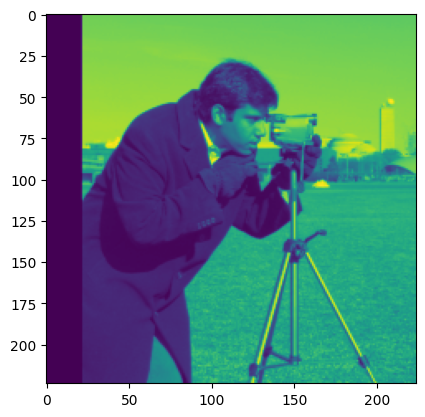

In [33]:
import matplotlib.pyplot as plt
plt.imshow(mockvideo_vid_data_tensor[10])

In [5]:
hr_feat_list = []
for frm_idx in range(mockvideo_vid_data_tensor.shape[0]):
    frm = mockvideo_vid_data_tensor[frm_idx, ...].permute(2, 0, 1) # (c, h, w)
    frm = torch.cat([frm for i in range(3)], dim=0)
    print("frm.shape: ", frm.shape)
    hr_feat = train_featup(cameraman=ImageFittingColorFeat(224, img_tensor=frm),
                 do_plot=False)
    print(hr_feat.shape)

    hr_feat_list.append(hr_feat)

mockvideo_hr_feat_2d = torch.stack(hr_feat_list, dim=0)
print(mockvideo_hr_feat_2d.shape)

frm.shape:  torch.Size([3, 224, 224])
self.img.shape:  torch.Size([3, 224, 224])
self.pixels.shape:  torch.Size([50176, 3])
self.combined_input_features.shape:  torch.Size([50176, 5])


C:\Users\ImmersionLab\miniconda3\envs\siren_featup\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using cache found in C:\Users\ImmersionLab/.cache\torch\hub\facebookresearch_dino_main


lr_feat_ground_truth_in_matrix.shape:  torch.Size([100, 384, 14, 14])


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

predicted_lr_feat_in_matrix.shape:  torch.Size([10, 384, 14, 14])
loss:  tensor(19.6434, device='cuda:0', grad_fn=<MeanBackward0>)
Step 0, Total loss 19.643444



...

tensor(19.1463, device='cuda:0', grad_fn=<MeanBackward0>)
predicted_lr_feat_in_matrix.shape:  torch.Size([10, 384, 14, 14])
loss:  

 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [00:33<00:04,  4.00s/it]

tensor(19.1414, device='cuda:0', grad_fn=<MeanBackward0>)
predicted_lr_feat_in_matrix.shape:  torch.Size([10, 384, 14, 14])
loss:  

 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [00:37<00:04,  4.15s/it]


KeyboardInterrupt: 

In [5]:
print(mockvideo_hr_feat_2d.shape)

torch.Size([30, 384, 224, 224])


In [6]:
mockvideo_feat_data = mockvideo_hr_feat_2d.detach().cpu().permute(0, 2, 3, 1).numpy()
np.save(rf'{WORK_DIR}\data\mock_videos\mockvideo_feat_data.npy', 
        mockvideo_feat_data)


## Repeat for ultrasound example

In [17]:
import pandas as pd
import numpy as np
import os
from PIL import Image
path = r"C:\data\ultrasound_db\musculoskeletal\dataset2\featup_demo"
def load_us_video(path, idx1=0, idx2=-1, step=1):
    df = pd.read_csv(os.path.join(path, 'tracking.csv'))
    im_files = list(df['frame_name'].drop_duplicates())
    vid_array = []
    for im_file in im_files[idx1:idx2:step]:
        frame = np.array(Image.open(os.path.join(path, 'images', im_file)).resize((224, 224), resample=Image.LANCZOS))
        vid_array.append(frame)
    return torch.Tensor(np.array(vid_array))[..., None]

us_vid = load_us_video(path, idx1=15, idx2=-15, step=3)

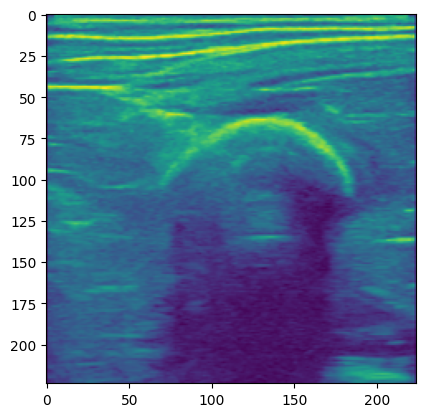

In [36]:
plt.imshow(us_vid[15])

In [23]:
hr_feat_list = []
for frm_idx in range(us_vid.shape[0]):
    frm = us_vid[frm_idx, ...].permute(2, 0, 1) # (c, h, w)
    frm = torch.cat([frm for i in range(3)], dim=0)
    print("frm.shape: ", frm.shape)
    hr_feat = train_featup(cameraman=ImageFittingColorFeat(224, img_tensor=frm),
                 do_plot=False)
    print(hr_feat.shape)

    hr_feat_list.append(hr_feat)

us_hr_feat = torch.stack(hr_feat_list, dim=0)

frm.shape:  torch.Size([3, 224, 224])
self.img.shape:  torch.Size([3, 224, 224])
self.pixels.shape:  torch.Size([50176, 3])
self.combined_input_features.shape:  torch.Size([50176, 5])


C:\Users\ImmersionLab\miniconda3\envs\siren_featup\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using cache found in C:\Users\ImmersionLab/.cache\torch\hub\facebookresearch_dino_main


lr_feat_ground_truth_in_matrix.shape:  torch.Size([100, 384, 14, 14])


  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

predicted_lr_feat_in_matrix.shape:  torch.Size([10, 384, 14, 14])
loss:  tensor(23.3812, device='cuda:0', grad_fn=<MeanBackward0>)
Step 0, Total loss 23.381218



...

tensor(22.8302, device='cuda:0', grad_fn=<MeanBackward0>)
predicted_lr_feat_in_matrix.shape:  torch.Size([10, 384, 14, 14])
loss:  

 90%|██████████████████████████████████████████████████████████████████████████▋        | 9/10 [00:58<00:06,  6.59s/it]

tensor(22.7656, device='cuda:0', grad_fn=<MeanBackward0>)
predicted_lr_feat_in_matrix.shape:  torch.Size([10, 384, 14, 14])
loss:  

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [01:05<00:00,  6.56s/it]

tensor(22.6439, device='cuda:0', grad_fn=<MeanBackward0>)
torch.Size([384, 224, 224])


In [26]:
us_feat_data = us_hr_feat.detach().cpu().permute(0, 2, 3, 1).numpy()
np.save(rf'{WORK_DIR}\data\mock_videos\us_feat_data.npy', us_feat_data)